# 03 · Baseline Model — Random Forest
**Project:** Eco-Urbanomics — Vehicle CO2 Emissions  
**Goal:** Train a strong Random Forest baseline for both classification (High_Emitter) and regression (CO2 g/km).  
**Priority metric:** Macro F1 for classification, RMSE + R² for regression.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)

PROCESSED = Path('../data/processed/processed_co2_data.csv')
MODELS    = Path('../models')
OUT_IMG   = Path('../data/outputs')
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED)
print(f"Loaded: {df.shape}")

TARGET_C = 'High_Emitter'
TARGET_R = 'CO2 Emissions(g/km)'
FEATURE_COLS = [c for c in df.columns if c not in [TARGET_C, TARGET_R]]

X = df[FEATURE_COLS].values
y_class = df[TARGET_C].values
y_reg   = df[TARGET_R].values

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"High Emitter rate — train: {yc_train.mean():.3f}  test: {yc_test.mean():.3f}")


Loaded: (7385, 22)
Train: (5908, 20)  |  Test: (1477, 20)
High Emitter rate — train: 0.304  test: 0.304


In [9]:
# ── Classification: Random Forest with class_weight='balanced' ─────────
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, yc_train)
print("Classification model trained.")


Classification model trained.


In [10]:
# ── Classification evaluation ──────────────────────────────────────────
yc_pred = rf_clf.predict(X_test)
yc_prob = rf_clf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  BASELINE — Classification Results")
print("=" * 55)
print(classification_report(yc_test, yc_pred,
      target_names=['Normal (0)', 'High Emitter (1)']))
print(f"  Macro F1   : {f1_score(yc_test, yc_pred, average='macro'):.4f}")
print(f"  ROC-AUC    : {roc_auc_score(yc_test, yc_prob):.4f}")
print("=" * 55)


  BASELINE — Classification Results
                  precision    recall  f1-score   support

      Normal (0)       1.00      0.99      0.99      1028
High Emitter (1)       0.98      0.99      0.99       449

        accuracy                           0.99      1477
       macro avg       0.99      0.99      0.99      1477
    weighted avg       0.99      0.99      0.99      1477

  Macro F1   : 0.9912
  ROC-AUC    : 0.9997


d:\code\eco-urbanomics\.conda\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


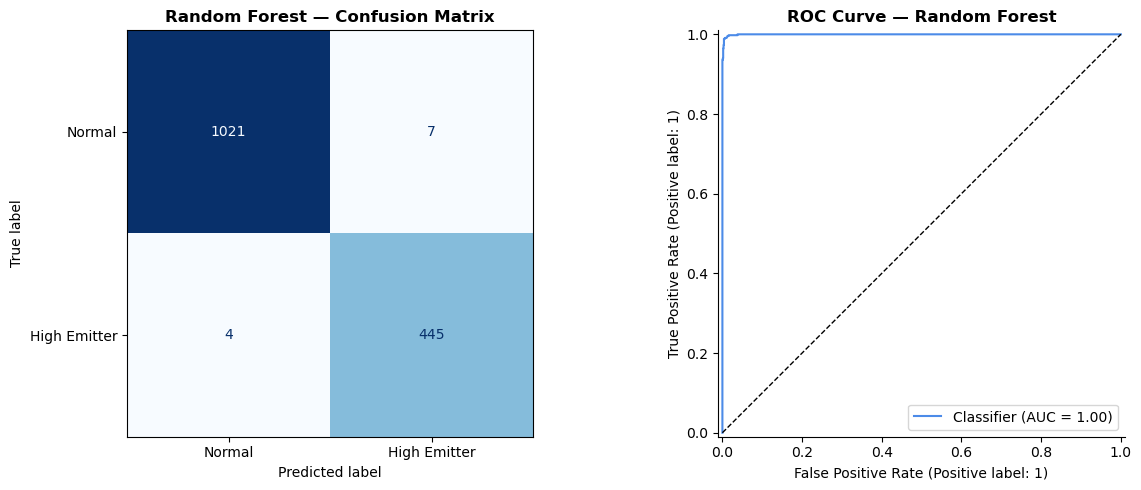

In [11]:
# ── Classification plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(yc_test, yc_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'High Emitter']
                       ).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(yc_test, yc_prob, ax=axes[1], color='#4C8BE8')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curve — Random Forest', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_IMG / 'baseline_classification.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── Regression: Random Forest ─────────────────────────────────────────
rf_reg = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, yr_train)
yr_pred = rf_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
mae  = mean_absolute_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)

print("=" * 45)
print("  BASELINE — Regression Results")
print("=" * 45)
print(f"  RMSE  : {rmse:.2f} g/km")
print(f"  MAE   : {mae:.2f} g/km")
print(f"  R²    : {r2:.4f}")
print("=" * 45)


  BASELINE — Regression Results
  RMSE  : 3.70 g/km
  MAE   : 2.12 g/km
  R²    : 0.9956


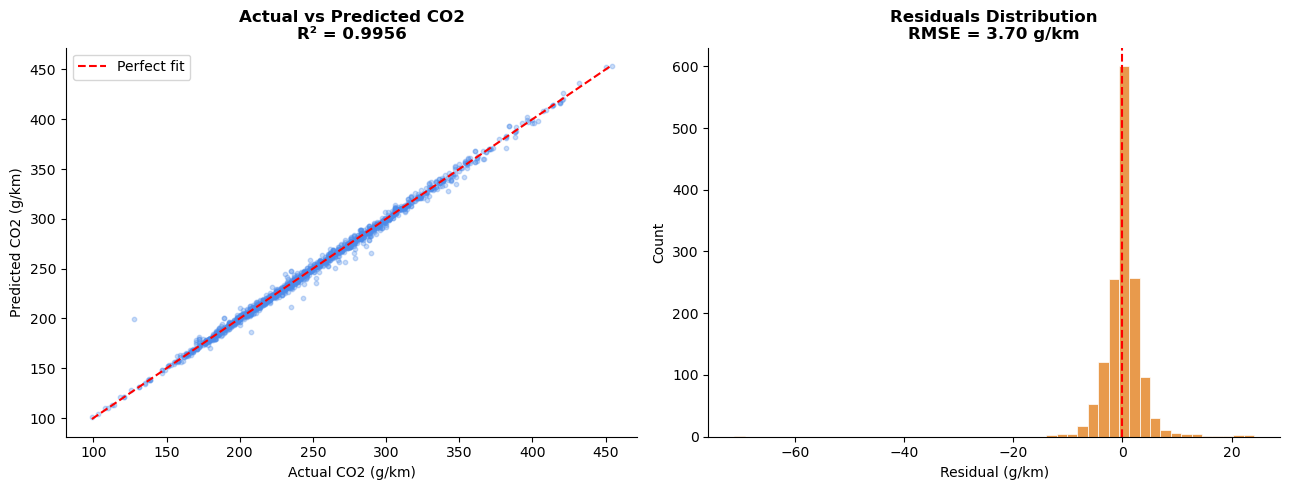

In [13]:
# ── Regression plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(yr_test, yr_pred, alpha=0.3, color='#4C8BE8', s=10)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual CO2 (g/km)')
axes[0].set_ylabel('Predicted CO2 (g/km)')
axes[0].set_title(f'Actual vs Predicted CO2\nR² = {r2:.4f}', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Residuals
residuals = yr_test - yr_pred
axes[1].hist(residuals, bins=50, color='#E89A4C', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (g/km)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals Distribution\nRMSE = {rmse:.2f} g/km', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_IMG / 'baseline_regression.png', dpi=150, bbox_inches='tight')
plt.show()


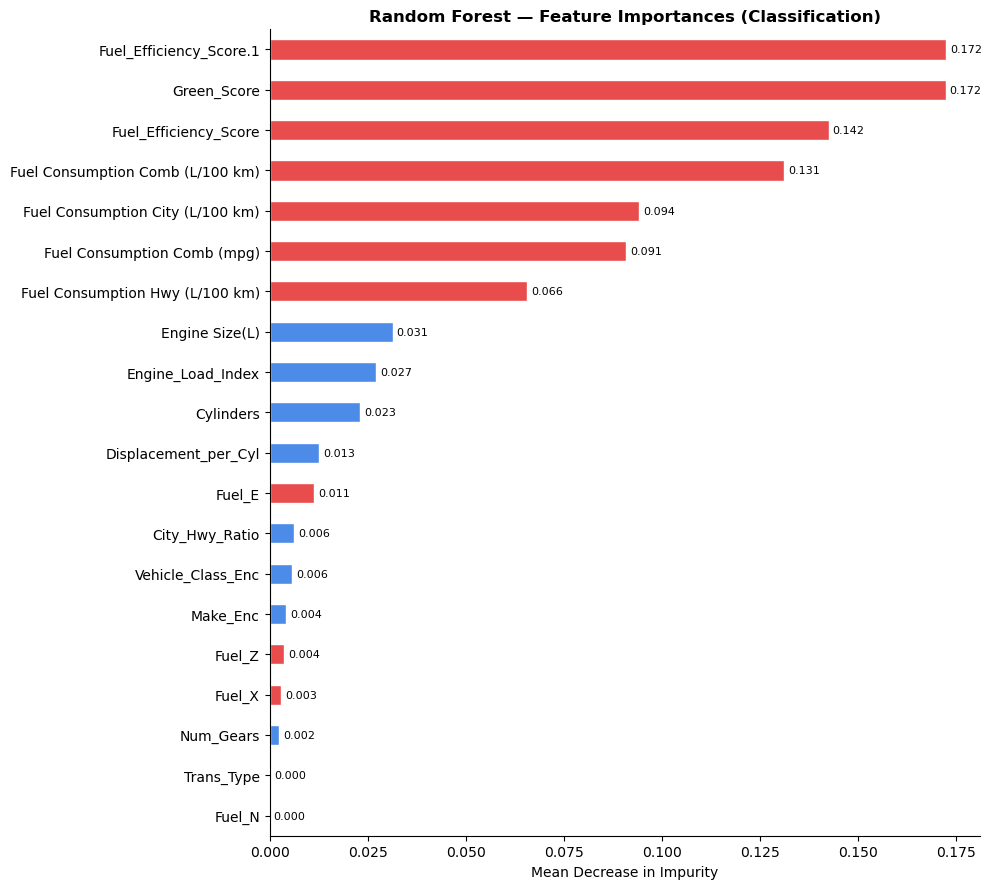

In [14]:
# ── Feature importance (classification) ───────────────────────────────
feat_imp = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS
                     ).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#E84C4C' if any(k in n for k in ['Green','Fuel','Efficiency','mpg'])
          else '#4C8BE8' for n in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances (Classification)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Decrease in Impurity')
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_IMG / 'baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# ── 5-fold cross validation ───────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf, X, y_class, cv=cv,
                            scoring='f1_macro', n_jobs=-1)
print(f"5-Fold CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold: {np.round(cv_scores, 4)}")


5-Fold CV Macro F1: 0.9885 ± 0.0053
Per fold: [0.9873 0.992  0.9818 0.9848 0.9968]


In [16]:
# ── Save models ───────────────────────────────────────────────────────
joblib.dump(rf_clf, MODELS / 'baseline_rf_clf.pkl')
joblib.dump(rf_reg, MODELS / 'baseline_rf_reg.pkl')
print(f"Saved → {MODELS/'baseline_rf_clf.pkl'}")
print(f"Saved → {MODELS/'baseline_rf_reg.pkl'}")


Saved → ..\models\baseline_rf_clf.pkl
Saved → ..\models\baseline_rf_reg.pkl
